In [1]:
import os
import pandas as pd

# Define base path relative to notebook location
BASE_PATH = os.path.abspath(os.path.join(".."))
DATA_PATH = os.path.join(BASE_PATH, "data")

print("Base path:", BASE_PATH)
print("Data path:", DATA_PATH)

Base path: c:\Users\dubey\Documents\UC_GitLab\Spring_2026_BI_Sem_1\CaseStudy2_SentimentAnalysis
Data path: c:\Users\dubey\Documents\UC_GitLab\Spring_2026_BI_Sem_1\CaseStudy2_SentimentAnalysis\data


In [2]:
csv_file = os.path.join(DATA_PATH, "Tweets.csv")
print("Looking for:", csv_file)

df = pd.read_csv(csv_file)

print("Loaded! Shape:", df.shape)
df.head(3)

Looking for: c:\Users\dubey\Documents\UC_GitLab\Spring_2026_BI_Sem_1\CaseStudy2_SentimentAnalysis\data\Tweets.csv
Loaded! Shape: (14640, 15)


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)


In [3]:
# Check column names
print("Columns:")
print(df.columns.tolist())

# Check sentiment distribution
print("\nSentiment Distribution:")
sentiment_counts = df["airline_sentiment"].value_counts()
print(sentiment_counts)

# Check percentage distribution
print("\nSentiment Percentage:")
print((sentiment_counts / len(df) * 100).round(2))

Columns:
['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']

Sentiment Distribution:
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

Sentiment Percentage:
airline_sentiment
negative    62.69
neutral     21.17
positive    16.14
Name: count, dtype: float64


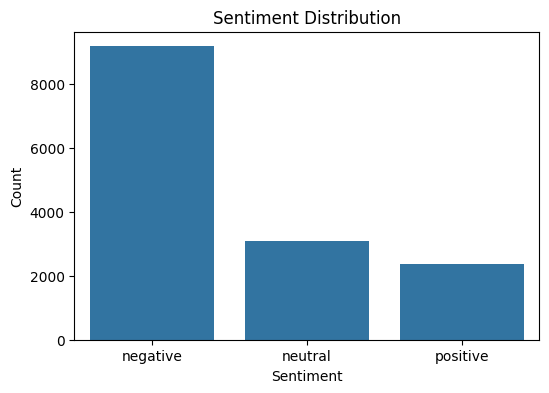

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="airline_sentiment",
              order=sentiment_counts.index)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [5]:
# Keep only relevant columns
df = df[["text", "airline_sentiment"]]

# Rename for simplicity (optional but clean)
df.columns = ["text", "label"]

print("New shape:", df.shape)
df.head()

New shape: (14640, 2)


,text,label
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


In [6]:
import re

def clean_text(text):
    # Lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    
    # Remove @mentions
    text = re.sub(r"@\w+", "", text)
    
    # Remove RT
    text = re.sub(r"\brt\b", "", text)
    
    # Remove numbers
    text = re.sub(r"\d+", "", text)
    
    # Remove punctuation
    text = re.sub(r"[^\w\s]", "", text)
    
    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [7]:
# Apply cleaning function
df["clean_text"] = df["text"].apply(clean_text)

# Show before vs after
df[["text", "clean_text"]].head(5)

,text,clean_text
0,@VirginAmerica What @dhepburn said.,what said
1,@VirginAmerica plus you've added commercials t...,plus youve added commercials to the experience...
2,@VirginAmerica I didn't today... Must mean I n...,i didnt today must mean i need to take another...
3,@VirginAmerica it's really aggressive to blast...,its really aggressive to blast obnoxious enter...
4,@VirginAmerica and it's a really big bad thing...,and its a really big bad thing about it


In [8]:
from sklearn.model_selection import train_test_split

X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

print("\nTrain label distribution (%):")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTest label distribution (%):")
print((y_test.value_counts(normalize=True) * 100).round(2))

Train size: 11712
Test size: 2928

Train label distribution (%):
label
negative    62.70
neutral     21.17
positive    16.14
Name: proportion, dtype: float64

Test label distribution (%):
label
negative    62.67
neutral     21.17
positive    16.15
Name: proportion, dtype: float64


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words="english"
)

# Fit only on training data
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform test data
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF Train Shape:", X_train_tfidf.shape)
print("TF-IDF Test Shape:", X_test_tfidf.shape)

TF-IDF Train Shape: (11712, 5000)
TF-IDF Test Shape: (2928, 5000)


In [10]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix

# Train model
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# Predict
y_pred_nb = nb_model.predict(X_test_tfidf)

# Evaluation
print("=== Naive Bayes Classification Report ===")
print(classification_report(y_test, y_pred_nb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

=== Naive Bayes Classification Report ===
              precision    recall  f1-score   support

    negative       0.72      0.98      0.83      1835
     neutral       0.67      0.24      0.35       620
    positive       0.85      0.40      0.54       473

    accuracy                           0.73      2928
   macro avg       0.75      0.54      0.57      2928
weighted avg       0.73      0.73      0.68      2928


Confusion Matrix:
[[1793   30   12]
 [ 451  147   22]
 [ 244   41  188]]


In [11]:
from sklearn.svm import LinearSVC

# Train model
svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)

# Predict
y_pred_svm = svm_model.predict(X_test_tfidf)

# Evaluation
print("=== Linear SVM Classification Report ===")
print(classification_report(y_test, y_pred_svm))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

=== Linear SVM Classification Report ===
              precision    recall  f1-score   support

    negative       0.83      0.88      0.85      1835
     neutral       0.56      0.53      0.54       620
    positive       0.74      0.61      0.67       473

    accuracy                           0.76      2928
   macro avg       0.71      0.67      0.69      2928
weighted avg       0.76      0.76      0.76      2928


Confusion Matrix:
[[1616  168   51]
 [ 239  328   53]
 [  95   89  289]]


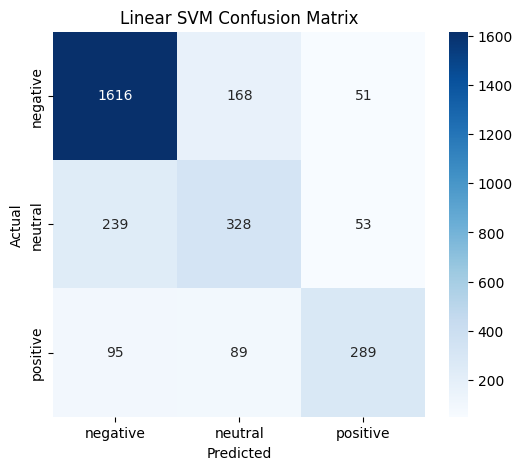

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=svm_model.classes_,
            yticklabels=svm_model.classes_,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Linear SVM Confusion Matrix")
plt.show()

In [13]:
import numpy as np

feature_names = tfidf.get_feature_names_out()
coef = svm_model.coef_

# Function to print top features
def top_features(class_index, class_name, top_n=15):
    top_positive = np.argsort(coef[class_index])[-top_n:]
    print(f"\nTop words for class: {class_name}")
    print(", ".join(feature_names[top_positive]))

# Print for each class
for i, class_label in enumerate(svm_model.classes_):
    top_features(i, class_label)


Top words for class: negative
forced, sleeping, screwed, worse, solution, error, hrs, disappointed, ridiculous, hour, hours, fail, hold, delayed, worst

Top words for class: neutral
fans, listen, jblu, guess im, care thanks, fb, accidentally, flight number, delays cancelled, horrible service, dal, flyingitforward, brother, care team, hi

Top words for class: positive
thanks, friendliest, appreciate, best, thx, thank, excited, love, exceptional, wonderful, amazing, excellent, kudos, awesome, great


In [14]:
from sklearn.svm import LinearSVC

# Weighted SVM
svm_weighted = LinearSVC(class_weight="balanced")
svm_weighted.fit(X_train_tfidf, y_train)

y_pred_svm_w = svm_weighted.predict(X_test_tfidf)

print("=== Weighted Linear SVM Classification Report ===")
print(classification_report(y_test, y_pred_svm_w))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm_w))

=== Weighted Linear SVM Classification Report ===
              precision    recall  f1-score   support

    negative       0.86      0.83      0.84      1835
     neutral       0.53      0.61      0.56       620
    positive       0.68      0.64      0.66       473

    accuracy                           0.75      2928
   macro avg       0.69      0.69      0.69      2928
weighted avg       0.76      0.75      0.76      2928


Confusion Matrix:
[[1520  238   77]
 [ 179  376   65]
 [  71   97  305]]


In [15]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

log_model.fit(X_train_tfidf, y_train)

y_pred_log = log_model.predict(X_test_tfidf)

print("=== Logistic Regression Classification Report ===")
print(classification_report(y_test, y_pred_log))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

=== Logistic Regression Classification Report ===
              precision    recall  f1-score   support

    negative       0.89      0.77      0.83      1835
     neutral       0.51      0.69      0.59       620
    positive       0.67      0.68      0.68       473

    accuracy                           0.74      2928
   macro avg       0.69      0.72      0.70      2928
weighted avg       0.77      0.74      0.75      2928


Confusion Matrix:
[[1422  316   97]
 [ 127  430   63]
 [  52   98  323]]


In [16]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

print("Label mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{label} -> {i}")

Label mapping:
negative -> 0
neutral -> 1
positive -> 2


In [17]:
from datasets import Dataset

train_ds = Dataset.from_dict({
    "text": X_train.tolist(),
    "label": y_train_enc.tolist()
})

test_ds = Dataset.from_dict({
    "text": X_test.tolist(),
    "label": y_test_enc.tolist()
})

print(train_ds)
print(test_ds)
print("\nSample row:", train_ds[0])

Dataset({
    features: ['text', 'label'],
    num_rows: 11712
})
Dataset({
    features: ['text', 'label'],
    num_rows: 2928
})

Sample row: {'text': 'what would it cost', 'label': 1}


In [18]:
from transformers import AutoTokenizer

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=64
    )

train_tok = train_ds.map(tokenize_batch, batched=True)
test_tok = test_ds.map(tokenize_batch, batched=True)

# Set format for PyTorch
train_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

print(train_tok)
print("\nTokenized sample:", train_tok[0])

Map:   0%|          | 0/11712 [00:00<?, ? examples/s]

Map:   0%|          | 0/2928 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 11712
})

Tokenized sample: {'label': tensor(1), 'input_ids': tensor([ 101, 2054, 2052, 2009, 3465,  102,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])}


In [19]:
import numpy as np
from transformers import AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

num_labels = 3

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average="macro"
    )
    acc = accuracy_score(labels, predictions)
    
    return {
        "accuracy": acc,
        "macro_f1": f1,
        "precision": precision,
        "recall": recall
    }

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [20]:
import transformers
print(transformers.__version__)

5.2.0


In [21]:
import sys
print(sys.executable)

c:\Users\dubey\Documents\UC_GitLab\.venv_global\Scripts\python.exe


In [22]:
import accelerate
import transformers
print("accelerate:", accelerate.__version__)
print("transformers:", transformers.__version__)

accelerate: 1.12.0
transformers: 5.2.0


In [24]:
import torch
from transformers import TrainingArguments, Trainer

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

training_args = TrainingArguments(
    output_dir="../reports/distilbert_runs",
    eval_strategy="epoch",          # ✅ transformers 5.x
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    report_to=[]                    # avoids wandb prompts
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=test_tok,
    compute_metrics=compute_metrics
)

print("Trainer ready.")

Device: cpu
Trainer ready.


In [25]:
trainer.train()

c:\Users\dubey\Documents\UC_GitLab\.venv_global\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Precision,Recall
1,0.454822,0.443600,0.824795,0.767373,0.783050,0.754199
2,0.346442,0.451215,0.827527,0.774797,0.785132,0.765677


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\dubey\Documents\UC_GitLab\.venv_global\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=1464, training_loss=0.43972995893551353, metrics={'train_runtime': 4772.4624, 'train_samples_per_second': 4.908, 'train_steps_per_second': 0.307, 'total_flos': 387871460278272.0, 'train_loss': 0.43972995893551353, 'epoch': 2.0})

In [26]:
eval_metrics = trainer.evaluate()
eval_metrics

c:\Users\dubey\Documents\UC_GitLab\.venv_global\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 0.45121482014656067,
 'eval_accuracy': 0.8275273224043715,
 'eval_macro_f1': 0.7747973765481029,
 'eval_precision': 0.7851321376075018,
 'eval_recall': 0.7656772968322585,
 'eval_runtime': 66.2555,
 'eval_samples_per_second': 44.193,
 'eval_steps_per_second': 1.389,
 'epoch': 2.0}

In [27]:
predictions = trainer.predict(test_tok)

y_pred_bert = np.argmax(predictions.predictions, axis=1)

from sklearn.metrics import classification_report, confusion_matrix

print("=== DistilBERT Classification Report ===")
print(classification_report(y_test_enc, y_pred_bert,
                            target_names=label_encoder.classes_))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_enc, y_pred_bert))

c:\Users\dubey\Documents\UC_GitLab\.venv_global\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


=== DistilBERT Classification Report ===
              precision    recall  f1-score   support

    negative       0.88      0.91      0.90      1835
     neutral       0.68      0.66      0.67       620
    positive       0.79      0.73      0.76       473

    accuracy                           0.83      2928
   macro avg       0.79      0.77      0.77      2928
weighted avg       0.83      0.83      0.83      2928


Confusion Matrix:
[[1670  124   41]
 [ 163  409   48]
 [  59   70  344]]


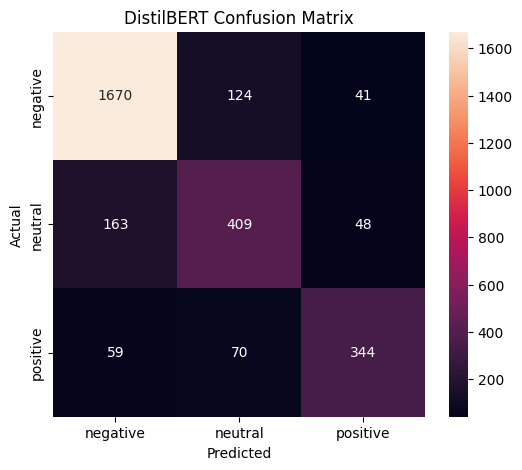

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

cm_bert = confusion_matrix(y_test_enc, y_pred_bert)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_bert, annot=True, fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DistilBERT Confusion Matrix")
plt.show()

In [29]:
# Reload original dataframe (with negativereason column)
df_full = pd.read_csv(os.path.join(DATA_PATH, "Tweets.csv"))

# Filter negative tweets
df_negative = df_full[df_full["airline_sentiment"] == "negative"]

# Count negative reasons
neg_reason_counts = df_negative["negativereason"].value_counts()

print(neg_reason_counts)

negativereason
Customer Service Issue         2910
Late Flight                    1665
Can't Tell                     1190
Cancelled Flight                847
Lost Luggage                    724
Bad Flight                      580
Flight Booking Problems         529
Flight Attendant Complaints     481
longlines                       178
Damaged Luggage                  74
Name: count, dtype: int64


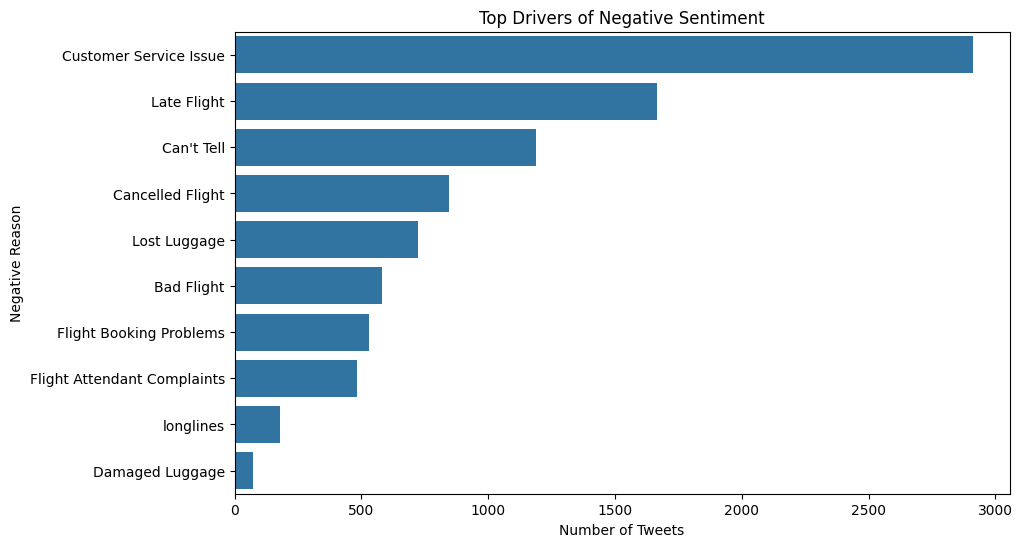

In [30]:
plt.figure(figsize=(10,6))
sns.barplot(
    x=neg_reason_counts.values,
    y=neg_reason_counts.index
)

plt.title("Top Drivers of Negative Sentiment")
plt.xlabel("Number of Tweets")
plt.ylabel("Negative Reason")
plt.show()